In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
df=pd.read_csv('Algerian_forest_fires_dataset_cleaned_dataset.csv')

In [11]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [12]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [13]:
##drop month,day and yyear
df.drop(['day','month','year'],axis=1,inplace=True)

In [14]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [15]:
df['Classes'].value_counts()

Classes
fire             131
not fire          98
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [16]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [17]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
235,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
236,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
237,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
238,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
239,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [18]:
df['Classes'].value_counts()

Classes
1    137
0    103
Name: count, dtype: int64

In [19]:
## Independent And dependent features
X=df.drop('FWI',axis=1)
y=df['FWI']

In [20]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [21]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
235    6.5
236    0.0
237    0.2
238    0.7
239    0.5
Name: FWI, Length: 240, dtype: float64

In [22]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [23]:
X_train.shape,X_test.shape

((180, 11), (60, 11))

In [24]:
## Feature Selection based on correlaltion
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.665096,-0.360453,-0.323382,0.686284,0.493958,0.389320,0.606687,0.469450,0.515305,0.255838
RH,-0.665096,1.000000,0.267826,0.211859,-0.619356,-0.365434,-0.185669,-0.679593,-0.310633,-0.398770,-0.390461
Ws,-0.360453,0.267826,1.000000,0.303319,-0.229800,-0.021053,0.056838,-0.057932,0.008139,-0.108548,-0.194943
Rain,-0.323382,0.211859,0.303319,1.000000,-0.539117,-0.272096,-0.286354,-0.332135,-0.282768,-0.369215,-0.063139
FFMC,0.686284,-0.619356,-0.229800,-0.539117,1.000000,0.604497,0.508735,0.741871,0.589524,0.760663,0.233498
DMC,0.493958,-0.365434,-0.021053,-0.272096,0.604497,1.000000,0.876616,0.678726,0.983756,0.604478,0.178568
DC,0.389320,-0.185669,0.056838,-0.286354,0.508735,0.876616,1.000000,0.508458,0.946668,0.524998,-0.117323
ISI,0.606687,-0.679593,-0.057932,-0.332135,0.741871,0.678726,0.508458,1.000000,0.635813,0.739261,0.269961
BUI,0.469450,-0.310633,0.008139,-0.282768,0.589524,0.983756,0.946668,0.635813,1.000000,0.595964,0.072510
Classes,0.515305,-0.398770,-0.108548,-0.369215,0.760663,0.604478,0.524998,0.739261,0.595964,1.000000,0.150208


<Axes: >

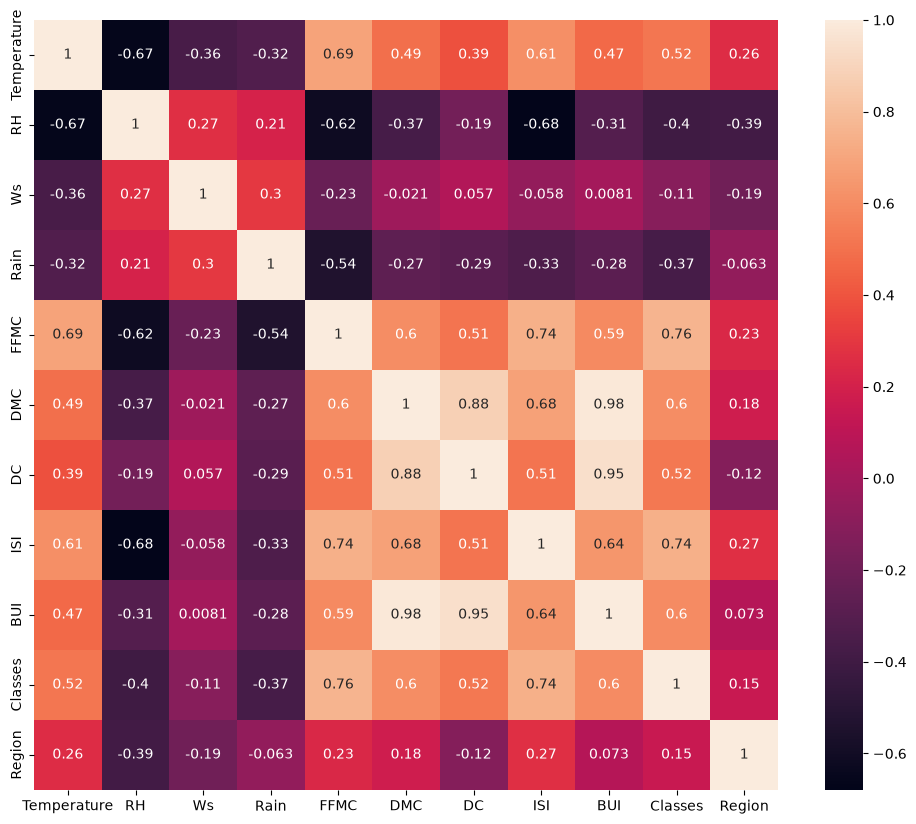

In [25]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


In [26]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.665096,-0.360453,-0.323382,0.686284,0.493958,0.389320,0.606687,0.469450,0.515305,0.255838
RH,-0.665096,1.000000,0.267826,0.211859,-0.619356,-0.365434,-0.185669,-0.679593,-0.310633,-0.398770,-0.390461
Ws,-0.360453,0.267826,1.000000,0.303319,-0.229800,-0.021053,0.056838,-0.057932,0.008139,-0.108548,-0.194943
Rain,-0.323382,0.211859,0.303319,1.000000,-0.539117,-0.272096,-0.286354,-0.332135,-0.282768,-0.369215,-0.063139
FFMC,0.686284,-0.619356,-0.229800,-0.539117,1.000000,0.604497,0.508735,0.741871,0.589524,0.760663,0.233498
DMC,0.493958,-0.365434,-0.021053,-0.272096,0.604497,1.000000,0.876616,0.678726,0.983756,0.604478,0.178568
DC,0.389320,-0.185669,0.056838,-0.286354,0.508735,0.876616,1.000000,0.508458,0.946668,0.524998,-0.117323
ISI,0.606687,-0.679593,-0.057932,-0.332135,0.741871,0.678726,0.508458,1.000000,0.635813,0.739261,0.269961
BUI,0.469450,-0.310633,0.008139,-0.282768,0.589524,0.983756,0.946668,0.635813,1.000000,0.595964,0.072510
Classes,0.515305,-0.398770,-0.108548,-0.369215,0.760663,0.604478,0.524998,0.739261,0.595964,1.000000,0.150208


In [27]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [28]:
## threshold--Domain expertise
corr_features=correlation(X_train,0.85)

In [29]:
corr_features

{'BUI', 'DC'}

In [30]:
## drop features when correlation is more than 0.85 
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((180, 9), (60, 9))

## Feature Scaling Or Standardization

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [32]:
X_train_scaled

array([[-0.85059547,  0.70039714,  0.56850263, ..., -0.79872371,
        -1.09321633, -0.9459053 ],
       [-1.11826538, -0.78121219,  0.56850263, ..., -0.77451181,
        -1.09321633,  1.05718828],
       [-1.65360518,  1.17181829,  0.17187289, ..., -1.06505462,
        -1.09321633, -0.9459053 ],
       ...,
       [-1.92127509,  0.90243477,  0.56850263, ..., -1.08926652,
        -1.09321633, -0.9459053 ],
       [ 1.55843366, -0.71386631, -0.6213866 , ..., -0.6534523 ,
        -1.09321633,  1.05718828],
       [-0.58292557,  0.96978065,  2.15502162, ..., -0.87135941,
        -1.09321633, -0.9459053 ]], shape=(180, 9))

## Box Plots To understand Effect Of Standard Scaler

Text(0.5, 1.0, 'X_train After Scaling')

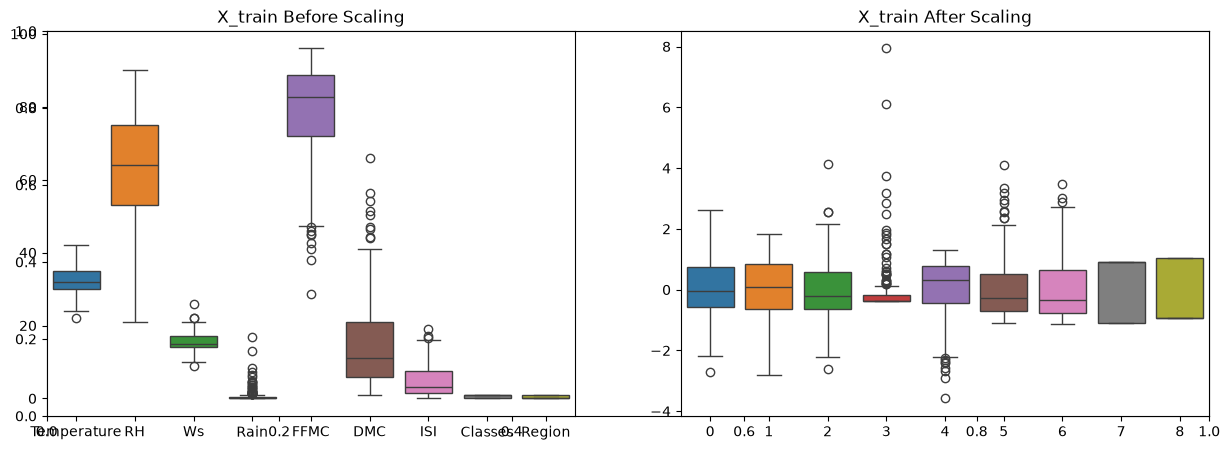

In [33]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression Model

Mean absolute error 0.7576778478881501
R2 Score 0.9773419493728723


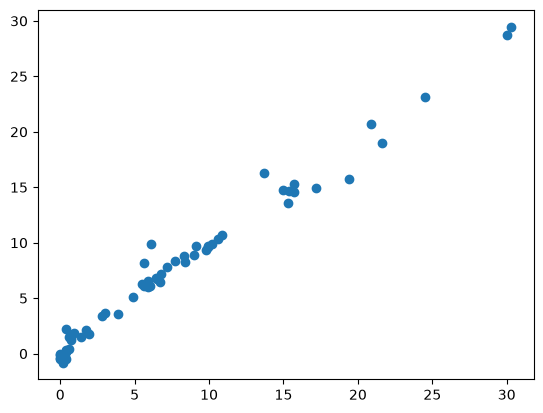

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Lasso Regression

Mean absolute error 1.337030760242974
R2 Score 0.9410175373336317


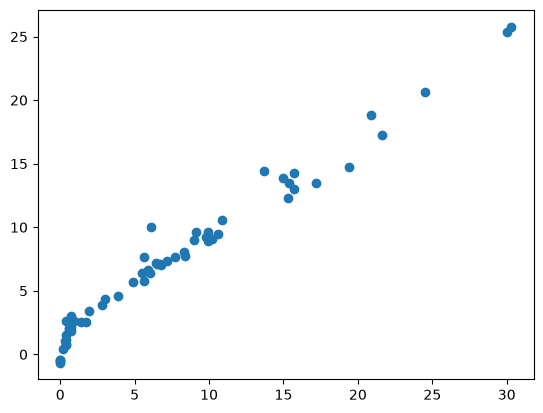

In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Cross Validation Lasso

In [36]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"positive positive: bool, default=FalseIf positive, restrict regression coefficients to be positive.",False


Mean absolute error 0.7632050073457856
R2 Score 0.977743440467773


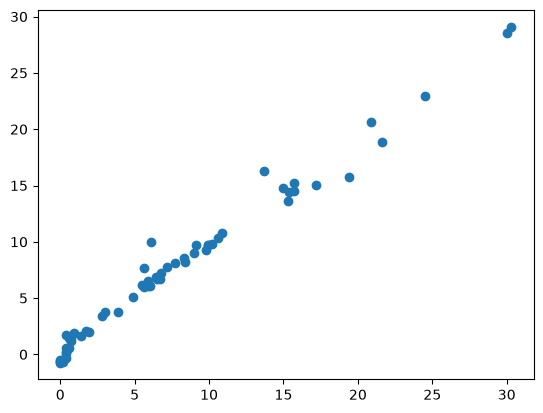

In [37]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression model

Mean absolute error 0.7817131646067164
R2 Score 0.9765944148035072


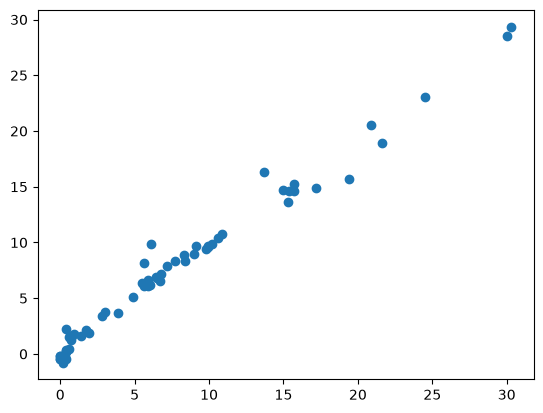

In [38]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.986812217756913
R2 Score 0.9684146959582765


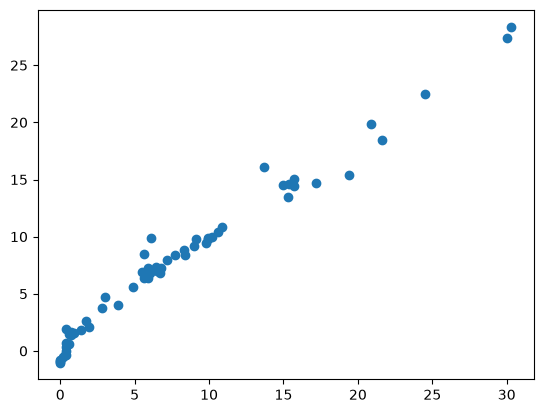

In [39]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [40]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## Elasticnet Regression

Mean absolute error 2.062292911367776
R2 Score 0.8650337485905482


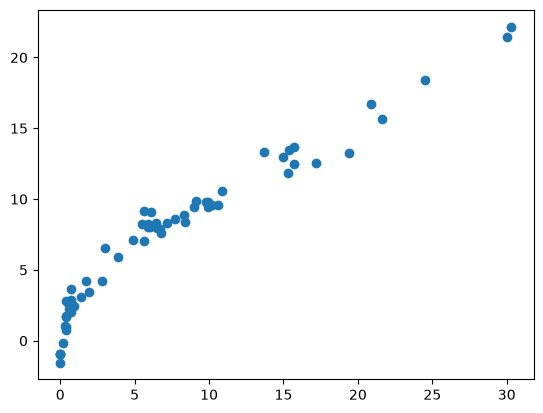

In [41]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.8634521826599002
R2 Score 0.9738099768326336


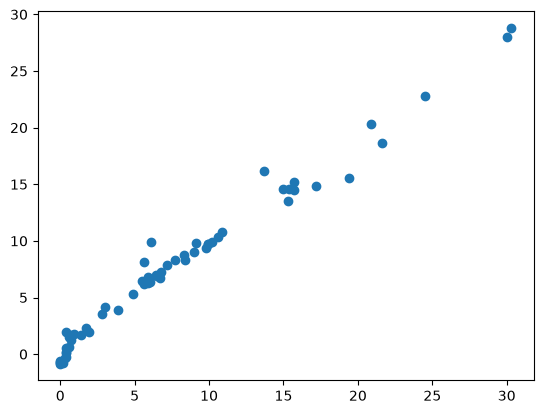

In [42]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [43]:
elasticcv.alphas_

array([13.51556466, 12.60466084, 11.75514888, 10.96289119, 10.22402902,
        9.53496368,  8.89233904,  8.29302515,  7.73410301,  7.21285035,
        6.72672838,  6.2733694 ,  5.8505653 ,  5.45625678,  5.08852333,
        4.74557389,  4.42573809,  4.12745816,  3.84928129,  3.58985262,
        3.34790857,  3.12227073,  2.91184014,  2.71559186,  2.53257005,
        2.36188331,  2.20270028,  2.05424565,  1.91579637,  1.78667811,
        1.66626198,  1.5539615 ,  1.4492297 ,  1.35155647,  1.26046608,
        1.17551489,  1.09628912,  1.0224029 ,  0.95349637,  0.8892339 ,
        0.82930251,  0.7734103 ,  0.72128504,  0.67267284,  0.62733694,
        0.58505653,  0.54562568,  0.50885233,  0.47455739,  0.44257381,
        0.41274582,  0.38492813,  0.35898526,  0.33479086,  0.31222707,
        0.29118401,  0.27155919,  0.25325701,  0.23618833,  0.22027003,
        0.20542457,  0.19157964,  0.17866781,  0.1666262 ,  0.15539615,
        0.14492297,  0.13515565,  0.12604661,  0.11755149,  0.10

In [44]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))